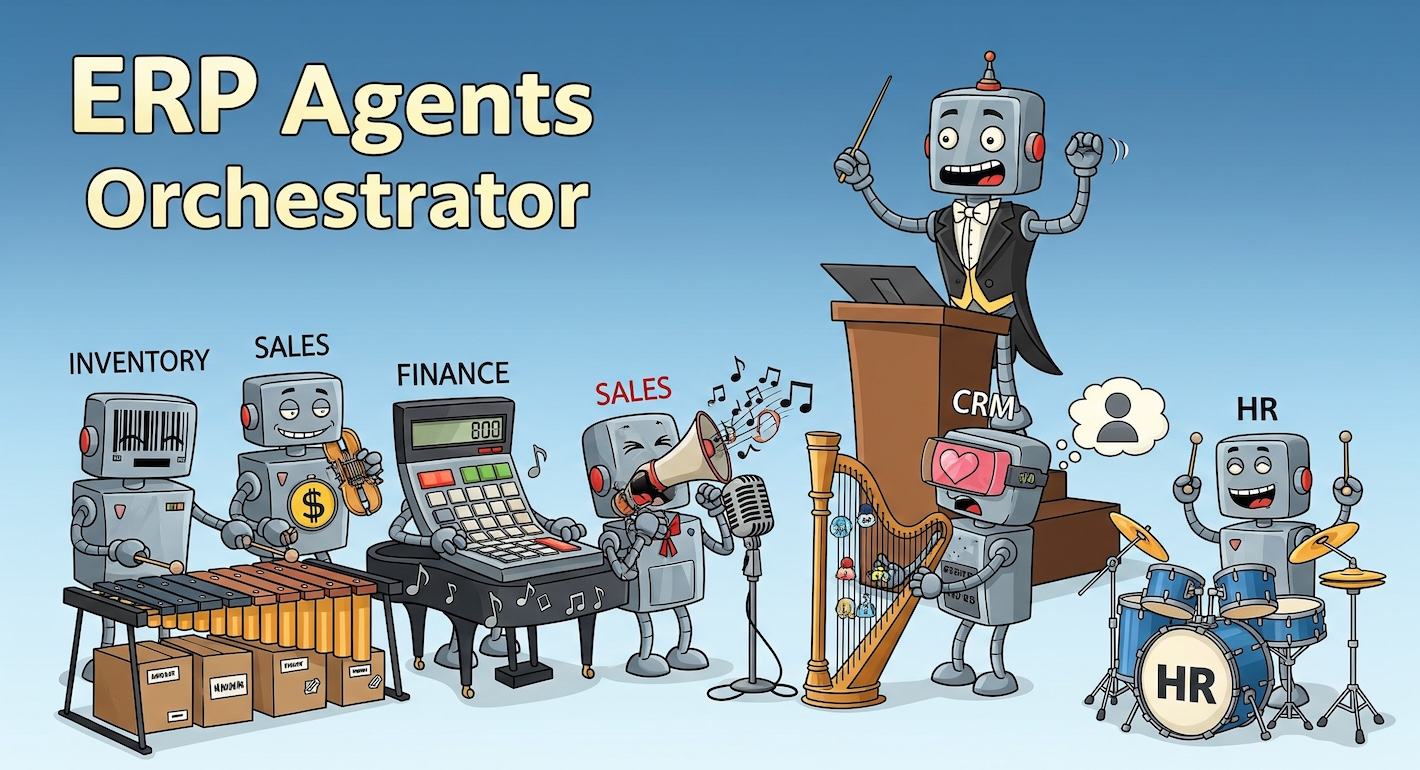

# ERP Agents Orchestrator

This notebook demonstrates the use of agents to simulate an Enterprise Resource Planning (ERP) system. It showcases how different specialized agents can handle various business functions and how a main ERP agent can route user requests to the appropriate sub-agent.

The notebook includes the following agents:

- **ERP Agent:** The main agent that directs user queries to the relevant specialized agent based on the topic of the request.
- **Inventory Management Agent:** Manages product inventory, including checking stock, listing products, adding stock, and updating product information.
- **Finance Management Agent:** Handles financial operations such as checking financials, recording expenses, and recording revenue.
- **Sales Management Agent:** Manages sales records, including checking sales and recording new sales.
- **CRM Agent:** Manages client relationships, including getting client information and adding new clients.
- **Purchasing Management Agent:** Manages purchasing operations, including checking purchases and placing orders.
- **Customer Service Agent:** Handles customer inquiries, including checking open queries and resolving queries.
- **HR Management Agent:** Manages human resources, including getting employee information and adding new employees.
- **Manufacturing Agent:** Oversees manufacturing processes, including checking production statistics and recording production.

This setup demonstrates a modular approach to building complex AI systems by breaking down tasks into smaller, specialized agents that can be orchestrated by a central agent.

In [ ]:
!pip install openai-agents -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.4/100.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
import nest_asyncio
from rich import  print
from openai import AsyncAzureOpenAI, AzureOpenAI
from google.colab import userdata
from agents import set_default_openai_client, set_default_openai_api, set_tracing_disabled
nest_asyncio.apply()
async_client = AsyncAzureOpenAI(api_key=userdata.get('AZURE_API_KEY'), azure_endpoint=userdata.get('AZURE_BASE_URL'), api_version=userdata.get('AZURE_API_VERSION'))
set_default_openai_client(async_client, use_for_tracing=False)
set_default_openai_api("chat_completions")
set_tracing_disabled(True)
from agents import Agent, Runner, RunContextWrapper, ModelSettings, function_tool, ItemHelpers
from pydantic import BaseModel
from typing import Dict, List, Optional
from dataclasses import dataclass

In [ ]:
#@title Testing Agents multiple outputs
# Mock data structures
testing_inventory_db = {
    "service_audit": 10,
    "service_consulting": 5,
    "service_tax": 8,
}

clients_db: Dict[str, List[str]] = {}  # Client name mapped to their projects

# Define the result models
class InventoryResult(BaseModel):
    service: str
    availability: int

class ClientProjectsResult(BaseModel):
    client: str
    projects: List[str]

@dataclass
class InventoryItem:
    client: str

# Function to check service availability
@function_tool
def check_service_availability(service: str) -> InventoryResult:
    # service = ctx.deps
    availability = testing_inventory_db.get(service, 0)
    return InventoryResult(service=service, availability=availability)

# Function to add a client
@function_tool
def add_client(client_name: str) -> str:
    """
    Add a new client, usually the client name is a real name or company name.
    """
    if client_name not in clients_db:
        clients_db[client_name] = []
        return f"Client {client_name} added successfully."
    else:
        return f"Client {client_name} already exists."

# Function to add a project for a client
@function_tool
def add_project(client_name: str, project_name: str) -> str:
    """
    Add a project for a client, when the client exists.
    """
    if client_name in clients_db:
        clients_db[client_name].append(project_name)
        return f"Project '{project_name}' added for client '{client_name}'."
    else:
        return f"Client {client_name} does not exist."

# Function to get projects for a client
@function_tool
def get_client_projects(wrapper: RunContextWrapper[str]) -> ClientProjectsResult:
    """
    Get projects for a client.
    """
    # client_name = wrapper.context
    # client_name = wrapper.context.name
    projects = clients_db.get(wrapper.context, [])
    return ClientProjectsResult(client=wrapper.context, projects=projects)


# Create the ERP agent
agent = Agent[str](
    name="Inventory Agent",
    instructions="You are an ERP agent managing services and clients for a technology company.",
    tools=[
        check_service_availability,
        add_client,
        add_project,
        get_client_projects,
    ]
)

# Run the agent
# Check service availability
result = Runner.run_sync(agent, 'Check availability for service_audit')
print(result.final_output) # Should print the availability for service_audit

# # Add a new client
print('-'*20)
result = Runner.run_sync(agent, 'Add client: Acme Corp')
print(result.final_output) # Should confirm the addition of the client

# # Add a project for the client
print('-'*20)
result = Runner.run_sync(agent, 'Add projects "Q1 Audit" and "Q4 Analysis" for client Acme Corp')
print(result.final_output) # Should confirm the addition of the project

# # Get projects for the client
print('-'*20)
result = Runner.run_sync(agent, 'Get projects',context='Acme Corp')
print(result.final_output)  # Should list the projects for Acme Corp

print('-'*20)
clients_db

The "service_audit" is available, with 10 slots remaining. If you need further assistance, feel free to ask!

--------------------

The client "Acme Corp" has been added successfully.

--------------------

The projects "Q1 Audit" and "Q4 Analysis" have been successfully added for the client Acme Corp.

--------------------

Here are the projects for the client "Acme Corp":

1. **Q1 Audit**
2. **Q4 Analysis**

If you need more information about these projects or wish to manage them further, please let me know!

--------------------

{'Acme Corp': ['Q1 Audit', 'Q4 Analysis']}

# ERP agents

# Inventory Management Agent

In [ ]:
#@title ###code
# Mock Data Structure
inventory_db: Dict[str, Dict[str, str | int]] = {
    "Smartphone X": {"stock": 100, "category": "Electronics", "price": 799, "description": "Latest Smartphone X with advanced features"},
    "Wireless Headphones": {"stock": 50, "category": "Accessories", "price": 199, "description": "Noise-cancelling wireless headphones"},
    "Gaming Laptop": {"stock": 30, "category": "Laptop", "price": 1499, "description": "High-performance gaming laptop"},
}

# Result Model
class InventoryResult(BaseModel):
    product: str
    stock: int
    category: str
    price: int
    description: str

# Functions
@function_tool
def check_stock(product: str) -> InventoryResult:
    product_info = inventory_db.get(product, None)
    if product_info:
        return InventoryResult(
            product=product,
            stock=product_info["stock"],
            category=product_info["category"],
            price=product_info["price"],
            description=product_info["description"]
        )
    else:
        return InventoryResult(product=product, stock=0, category="", price=0, description="Product does not exist.")

@function_tool
def list_all_products() -> List[str]:
    """
    List all products in the inventory.
    """
    return list(inventory_db.keys())

@function_tool
def add_stock(product: str, amount: int) -> str:
    if product in inventory_db:
        inventory_db[product]["stock"] += amount
        return f"Added {amount} to {product}. New stock: {inventory_db[product]['stock']}"
    else:
        return f"Product {product} does not exist."

@function_tool
def update_product_info(product: str, category: str, price: int, description: str) -> str:
    if product in inventory_db:
        inventory_db[product].update({
            "category": category,
            "price": price,
            "description": description
        })
        return f"Updated {product} information successfully."
    else:
        return f"Product {product} does not exist."

# Create the Agent
inventory_agent = Agent(
    name="Inventory Agent",
    model="gpt-4o-2",
    output_type=InventoryResult,
    instructions="You are an inventory management agent for a retail company.",
    tools=[
        check_stock,
        add_stock,
        update_product_info,
        list_all_products,
    ]
)

# Example Usage
result = Runner.run_sync(inventory_agent, 'Check stock for Smartphone X')
print(result.final_output)

result = Runner.run_sync(inventory_agent, 'Add 20 stock to Wireless Headphones')
print(result.final_output)

result = Runner.run_sync(inventory_agent, 'Update Gaming Laptop, price 1399 with latest specs')
print(result.final_output)

result = Runner.run_sync(inventory_agent.clone(output_type=str), 'list all products')
print(result.final_output)

result = Runner.run_sync(inventory_agent.clone(output_type=str), 'check the stock of all products')
print(result.final_output)

# raise error
# result = Runner.run_sync(inventory_agent, 'check the stock of all products')
# print(result.final_output)

InventoryResult(
    product='Smartphone X',
    stock=100,
    category='Electronics',
    price=799,
    description='Latest Smartphone X with advanced features'
)

InventoryResult(
    product='Wireless Headphones',
    stock=70,
    category='Accessories',
    price=199,
    description='Noise-cancelling wireless headphones'
)

InventoryResult(
    product='Gaming Laptop',
    stock=30,
    category='Laptop',
    price=1399,
    description='A high-performance gaming laptop equipped with latest specifications for an ultimate gaming 
experience.'
)

Here are all the products listed in the inventory:

1. **Smartphone X**
2. **Wireless Headphones**
3. **Gaming Laptop**

Here is the current stock of all products:

1. **Smartphone X**
   - Stock: 100 units
   - Category: Electronics
   - Price: $799
   - Description: Latest Smartphone X with advanced features.

2. **Wireless Headphones**
   - Stock: 70 units
   - Category: Accessories
   - Price: $199
   - Description: Noise-cancelling wireless headphones.

3. **Gaming Laptop**
   - Stock: 30 units
   - Category: Electronics
   - Price: $1399
   - Description: A high-performance gaming laptop equipped with the latest specifications for an ultimate gaming 
experience.

# Finance Management Agent

In [ ]:
#@title ###code
# Mock Data Structure
finance_db: Dict[str, float] = {
    "total_revenue": 500000.0,
    "total_expenses": 300000.0,
    "net_profit": 200000.0,
}

# Result Model
class FinanceResult(BaseModel):
    revenue: float
    expenses: float
    net_profit: float

# Functions
@function_tool
def check_financials() -> FinanceResult:
    return FinanceResult(
        revenue=finance_db["total_revenue"],
        expenses=finance_db["total_expenses"],
        net_profit=finance_db["net_profit"]
    )

@function_tool
def record_expense(amount: float, description: str) -> str:
    finance_db["total_expenses"] += amount
    finance_db["net_profit"] = finance_db["total_revenue"] - finance_db["total_expenses"]
    return f"Recorded expense of {amount} for {description}."

@function_tool
def record_revenue(amount: float, description: str) -> str:
    finance_db["total_revenue"] += amount
    finance_db["net_profit"] = finance_db["total_revenue"] - finance_db["total_expenses"]
    return f"Recorded revenue of {amount} for {description}."

# Create the Agent
finance_agent = Agent(
    name="Finance Agent",
    model="gpt-4o-2",
    output_type=FinanceResult,
    instructions="You are a finance management agent for a corporate entity.",
    tools=[
        check_financials,
        record_expense,
        record_revenue,
    ]
)

# Example Usage
result = Runner.run_sync(finance_agent, 'Check financials')
print(result.final_output)

result = Runner.run_sync(finance_agent, 'Record expense of 500 for office supplies')
print(result.final_output)

result = Runner.run_sync(finance_agent, 'Record revenue of 10000 for project completion')
print(result.final_output)

FinanceResult(revenue=500000.0, expenses=300000.0, net_profit=200000.0)

FinanceResult(revenue=0.0, expenses=500.0, net_profit=-500.0)

FinanceResult(revenue=510000.0, expenses=300500.0, net_profit=209500.0)

# Sales Management Agent

In [ ]:
#@title ###code
# Mock Data Structure
sales_db: Dict[str, Dict[str, int]] = {
    "total_sales": 1500,
    "sales_by_product": {
        "Smartphone X": 300,
        "Wireless Headphones": 200,
        "Gaming Laptop": 100,
    },
}

# Result Model
class SalesResult(BaseModel):
    total_sales: int
    sales_by_product: str

# Functions
@function_tool
def check_sales() -> SalesResult:
    return SalesResult(
        total_sales=sales_db["total_sales"],
        sales_by_product=sales_db["sales_by_product"]
    )

@function_tool
def record_sale(product: str, quantity: int) -> str:
    if product in sales_db["sales_by_product"]:
        sales_db["sales_by_product"][product] += quantity
        sales_db["total_sales"] += quantity
        return f"Recorded sale of {quantity} units of {product}."
    else:
        return f"Product {product} does not exist in sales records."

# Create the Agent
sales_agent = Agent(
    name="Sales Agent",
    model="gpt-4o-2",
    output_type=SalesResult,
    instructions="You are a sales management agent for a retail company.",
    tools=[
        check_sales,
        record_sale,
    ],
    # output_schema_strict=False
)

# Example Usage
result = Runner.run_sync(sales_agent, 'Check sales')
print(result.final_output)

result = Runner.run_sync(sales_agent, 'Record sale of 5 units of Smartphone X')
print(result.final_output)

SalesResult(
    total_sales=920,
    sales_by_product='Smartphone X: 300, Wireless Headphones: 150, Fitness Tracker: 100, 4K Television: 250, Gaming
Laptop: 100'
)

SalesResult(
    total_sales=1220,
    sales_by_product='Smartphone X: 305, Wireless Earbuds: 420, Smartwatch Y: 270, Gaming Laptop: 100'
)

# CRM Agent

In [ ]:
#@title ###code
# Mock Data Structure
clients_db: Dict[str, Dict[str, List[str]]] = {
    "Acme Corp": {"contact": "John Doe", "projects": ["Project A", "Project B"]},
    "Beta LLC": {"contact": "Jane Smith", "projects": []},
}

# Result Model
class ClientResult(BaseModel):
    client: str
    contact: str
    projects: List[str]

# Functions
@function_tool
def get_client_info(client_name: str) -> ClientResult:
    client_info = clients_db.get(client_name)
    if client_info:
        return ClientResult(
            client=client_name,
            contact=client_info["contact"],
            projects=client_info["projects"]
        )
    else:
        return ClientResult(client=client_name, contact="", projects=[])

@function_tool
def add_client(client_name: str, contact: str) -> str:
    if client_name not in clients_db:
        clients_db[client_name] = {"contact": contact, "projects": []}
        return f"Client {client_name} added successfully."
    else:
        return f"Client {client_name} already exists."

# Create the Agent
crm_agent = Agent(
    name="CRM Agent",
    model="gpt-4o-2",
    output_type=ClientResult,
    instructions="You are a CRM agent managing client relationships.",
    tools=[
        get_client_info,
        add_client,
    ]
)

# Example Usage
result = Runner.run_sync(crm_agent, 'Get client info for Acme Corp')
print(result.final_output)

result = Runner.run_sync(crm_agent, 'Add client Beta LLC with contact Jane Smith')
print(result.final_output)

ClientResult(client='Acme Corp', contact='John Doe', projects=['Project A', 'Project B'])

ClientResult(client='Beta LLC ', contact='Jane Smith', projects=[])

# Purchasing Management Agent

In [ ]:
#@title ###code
# Mock Data Structure
purchases_db: Dict[str, Dict[str, float]] = {
    "total_purchases": 200000.0,
    "pending_orders": 5,
}

# Result Model
class PurchaseResult(BaseModel):
    total_purchases: float
    pending_orders: int

# Functions
@function_tool
def check_purchases() -> PurchaseResult:
    return PurchaseResult(
        total_purchases=purchases_db["total_purchases"],
        pending_orders=purchases_db["pending_orders"]
    )

@function_tool
def place_order(supplier: str, amount: float) -> str:
    purchases_db["total_purchases"] += amount
    purchases_db["pending_orders"] += 1
    return f"Placed order with {supplier} for {amount}."

# Create the Agent
purchasing_agent = Agent(
    name="Purchasing Agent",
    model="gpt-4o-2",
    output_type=PurchaseResult,
    instructions="You are a purchasing management agent for a retail company.",
    tools=[
        check_purchases,
        place_order,
    ]
)

# Example Usage
result = Runner.run_sync(purchasing_agent, 'Check purchases')
print(result.final_output)

result = Runner.run_sync(purchasing_agent, 'Place order with Supplier A for 15000')
print(result.final_output)

PurchaseResult(total_purchases=200000.0, pending_orders=5)

PurchaseResult(total_purchases=215000.0, pending_orders=6)

# Customer Service Agent

In [ ]:
#@title ###code
# Mock Data Structure
customer_queries_db: Dict[str, List[str]] = {
    "open_queries": ["Order #1234 delayed", "Product return request"],
    "resolved_queries": [],
}

# Result Model
class CustomerServiceResult(BaseModel):
    open_queries: List[str]
    resolved_queries: List[str]

# Functions
@function_tool
def check_customer_queries() -> CustomerServiceResult:
    """
    Check all customer queries.
    """
    return CustomerServiceResult(
        open_queries=customer_queries_db["open_queries"],
        resolved_queries=customer_queries_db["resolved_queries"]
    )

@function_tool
def resolve_query(query: str) -> str:
    """
    Resolve a given query.
    """
    print('Resolving...', query)
    if query in customer_queries_db["open_queries"]:
        customer_queries_db["open_queries"].remove(query)
        customer_queries_db["resolved_queries"].append(query)
        return f"Resolved query: {query}."
    else:
        return f"Query: {query} not found in open queries."

# Create the Agent
customer_service_agent = Agent(
    name="Customer Service Agent",
    model="gpt-4o-2",
    output_type=CustomerServiceResult,
    instructions="You are a customer service agent handling customer inquiries.\
        When the user requests checking, just check, not resolve anything.\
        Only resolve inquiries told by the user.",
    tools=[
        check_customer_queries,
        resolve_query,
    ]
)

# Example Usage
result = Runner.run_sync(customer_service_agent, 'Check customer queries')
print(result.final_output)

result = Runner.run_sync(customer_service_agent, 'Resolve query: Order #1234 delayed')
print(result.final_output)

result = Runner.run_sync(customer_service_agent, 'Check customer queries')
print(result.final_output)

CustomerServiceResult(open_queries=['Order #1234 delayed', 'Product return request'], resolved_queries=[])

Resolving... Order #1234 delayed

CustomerServiceResult(open_queries=[], resolved_queries=['Order #1234 delayed'])

CustomerServiceResult(open_queries=['Product return request'], resolved_queries=['Order #1234 delayed'])

# HR Management Agent

In [ ]:
#@title ###code
# Mock Data Structure
employees_db: Dict[str, Dict[str, str | int]] = {
    "John Doe": {"position": "Software Engineer", "salary": 80000, "status": "Active"},
    "Jane Smith": {"position": "Project Manager", "salary": 90000, "status": "Active"},
}

# Result Model
class HRResult(BaseModel):
    employee: str
    position: str
    salary: int
    status: str

# Functions
@function_tool
def get_employee_info(employee_name: str) -> HRResult:
    employee_info = employees_db.get(employee_name)
    if employee_info:
        return HRResult(
            employee=employee_name,
            position=employee_info["position"],
            salary=employee_info["salary"],
            status=employee_info["status"]
        )
    else:
        return HRResult(employee=employee_name, position="", salary=0, status="Not Found")

@function_tool
def add_employee(employee_name: str, position: str, salary: int) -> str:
    if employee_name not in employees_db:
        employees_db[employee_name] = {"position": position, "salary": salary, "status": "Active"}
        return f"Employee {employee_name} added successfully."
    else:
        return f"Employee {employee_name} already exists."

# Create the Agent
hr_agent = Agent(
    name="HR Agent",
    model="gpt-4o-2",
    output_type=HRResult,
    instructions="You are an HR management agent for a corporate entity.",
    tools=[
        get_employee_info,
        add_employee,
    ]
)

# Example Usage
result = Runner.run_sync(hr_agent, 'Get employee info for John Doe')
print(result.final_output)

result = Runner.run_sync(hr_agent, 'Add employee Alice Johnson as HR Manager with salary 75000')
print(result.final_output)

# Display current employees database
print(employees_db)

HRResult(employee='John Doe', position='Software Engineer', salary=80000, status='Active')

HRResult(employee='Alice Johnson', position='HR Manager', salary=75000, status='Employee added successfully.')

{
    'John Doe': {'position': 'Software Engineer', 'salary': 80000, 'status': 'Active'},
    'Jane Smith': {'position': 'Project Manager', 'salary': 90000, 'status': 'Active'},
    'Alice Johnson': {'position': 'HR Manager', 'salary': 75000, 'status': 'Active'}
}

# Manufacturing Agent

In [ ]:
#@title ###code
# Mock Data Structure
production_db: Dict[str, Dict[str, int]] = {
    "total_units_produced": 10000,
    "defective_units": 200,
}

# Result Model
class ManufacturingResult(BaseModel):
    total_units_produced: int
    defective_units: int

# Functions
@function_tool
def check_production_stats() -> ManufacturingResult:
    return ManufacturingResult(
        total_units_produced=production_db["total_units_produced"],
        defective_units=production_db["defective_units"]
    )

@function_tool
def record_production(units: int) -> str:
    production_db["total_units_produced"] += units
    return f"Recorded production of {units} units."

# Create the Agent
manufacturing_agent = Agent(
    name="Manufacturing Agent",
    model="gpt-4o-2",
    output_type=ManufacturingResult,
    instructions="You are a manufacturing agent overseeing production processes.",
    tools=[
        check_production_stats,
        record_production,
    ]
)

# Example Usage
result = Runner.run_sync(manufacturing_agent, 'Check production stats')
print(result.final_output)

result = Runner.run_sync(manufacturing_agent, 'Record production of 500 units')
print(result.final_output)

ManufacturingResult(total_units_produced=10000, defective_units=200)

ManufacturingResult(total_units_produced=10500, defective_units=200)

# Handoff ERP AI System

In [ ]:
# Handoffs are sub-agents
erp_agent = Agent(
    name="ERP agent",
    instructions=(
        "You are an ERP AI agent which can help the user with their questions."
        "Help the user with their questions."
        "If they ask about inventory, handoff to the inventory agent."
        "If they ask about finance, handoff to the finance agent."
        "If they ask about sales, handoff to the sales agent."
        "If they ask about CRM, handoff to the CRM agent."
        "If they ask about purchasing, handoff to the purchasing agent."
        "If they ask about customer service, handoff to the customer service agent."
        "If they ask about HR, handoff to the HR agent."
        "If they ask about manufacturing, handoff to the manufacturing agent."
    ),
    handoff_description="Use different agents for each agent",
    handoffs=[inventory_agent, finance_agent, sales_agent, crm_agent, purchasing_agent, customer_service_agent, hr_agent, manufacturing_agent],
    model="gpt-4o-2",
    output_type=str
)

In [ ]:
async def ask_to_ERP_AI_system(question: str):
    result = Runner.run_streamed(
        erp_agent,
        input=question,
    )
    print("=== Run starting ===")

    async for event in result.stream_events():
        # We'll ignore the raw responses event deltas
        if event.type == "raw_response_event":
            continue
        # When the agent updates, print that
        elif event.type == "agent_updated_stream_event":
            print(f"Agent updated: {event.new_agent.name}")
            continue
        # When items are generated, print them
        elif event.type == "run_item_stream_event":
            if event.item.type == "tool_call_item":
                print("-- Tool was called")
            elif event.item.type == "tool_call_output_item":
                print(f"-- Tool output: {event.item.output}")
            elif event.item.type == "message_output_item":
                print(f"-- Message output:\n {ItemHelpers.text_message_output(event.item)}")
            else:
                pass  # Ignore other event types

    print("=== Run complete ===")

In [ ]:
from agents import Agent, handoff


class EscalationData(BaseModel):
    reason: str

async def on_handoff(ctx: RunContextWrapper[None], input_data: EscalationData):
    print(f"Escalation agent called with reason: {input_data.reason}")


# Handoffs are sub-agents
erp_agent = Agent(
    name="ERP agent",
    instructions=(
        "You are an ERP AI agent which can help the user with their questions."
        "Help the user with their questions."
        "If they ask about inventory, handoff to the inventory agent."
        "If they ask about finance, handoff to the finance agent."
        "If they ask about sales, handoff to the sales agent."
        "If they ask about CRM, handoff to the CRM agent."
        "If they ask about purchasing, handoff to the purchasing agent."
        "If they ask about customer service, handoff to the customer service agent."
        "If they ask about HR, handoff to the HR agent."
        "If they ask about manufacturing, handoff to the manufacturing agent."
    ),
    handoff_description="Use different agents for each agent",
    handoffs=[handoff(inventory_agent.clone(output_type=str),on_handoff=on_handoff,input_type=EscalationData,),
              handoff(finance_agent.clone(output_type=str),on_handoff=on_handoff,input_type=EscalationData,),
              sales_agent.clone(output_type=str),
              crm_agent.clone(output_type=str),
              purchasing_agent.clone(output_type=str),
              customer_service_agent.clone(output_type=str),
              hr_agent.clone(output_type=str),
              manufacturing_agent.clone(output_type=str)],
    model="gpt-4o-2",
    output_type=str
)

In [ ]:
await ask_to_ERP_AI_system('Do two actions: record expense of 500 for office supplies  and then check stock for Smartphone X')

=== Run starting ===

Agent updated: ERP agent

Escalation agent called with reason: User needs to record an expense of 500 for office supplies.

-- Tool output: Multiple handoffs detected, ignoring this one.

Agent updated: Finance Agent

-- Tool was called

-- Tool output: Recorded expense of 500.0 for office supplies.

-- Message output:
 The expense of $500 for office supplies has been successfully recorded. 

Regarding the stock for Smartphone X, I'm unable to perform that check. You'll need to contact the inventory 
department or manager for that information. If you have any other finance-related tasks, feel free to ask!

=== Run complete ===

In [ ]:
result = await Runner.run(erp_agent, input='Who are you?')
print(result.final_output)

I am an ERP AI agent designed to help you with various questions and processes related to enterprise resource 
planning (ERP). I can assist you with questions related to inventory, finance, sales, CRM, purchasing, customer 
service, HR, and manufacturing by connecting you with the appropriate specialized agents for each area. How may I 
assist you today?

In [ ]:
result = await Runner.run(erp_agent, input='Check stock for Smartphone X')
print(result.final_output)

Escalation agent called with reason: The user wants to check the inventory for Smartphone X.

We currently have 100 units of **Smartphone X** in stock. It belongs to the **Electronics** category and is priced 
at **$799**. The product description states that it is the latest Smartphone X equipped with advanced features.

In [ ]:
await ask_to_ERP_AI_system('Check stock for Smartphone X')

=== Run starting ===

Agent updated: ERP agent

Escalation agent called with reason: User wants to check stock levels for Smartphone X

Agent updated: Inventory Agent

-- Tool was called

-- Tool output: product='Smartphone X' stock=100 category='Electronics' price=799 description='Latest Smartphone X 
with advanced features'

-- Message output:
 The current stock level for **Smartphone X** is 100 units. It belongs to the **Electronics** category, priced at 
$799, and features advanced specifications.

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Record expense of 500 for office supplies')

=== Run starting ===

Agent updated: ERP agent

Escalation agent called with reason: Record expense of 500 for office supplies

Agent updated: Finance Agent

-- Tool was called

-- Tool output: Recorded expense of 500.0 for office supplies.

-- Message output:
 The expense of $500 for office supplies has been recorded successfully.

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Record sale of 5 units of Smartphone X')

=== Run starting ===

Agent updated: ERP agent

Agent updated: Sales Agent

-- Tool was called

-- Tool output: Recorded sale of 5 units of Smartphone X.

-- Message output:
 The sale of 5 units of Smartphone X has been successfully recorded.

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Add client Beta LLC with contact Peter Parket in MAVEL project')

=== Run starting ===

Agent updated: ERP agent

Agent updated: CRM Agent

-- Tool was called

-- Tool output: Client Beta LLC already exists.

-- Tool was called

-- Tool output: client='Beta LLC' contact='Jane Smith' projects=[]

-- Message output:
 The client "Beta LLC" already exists in our system with the contact person listed as "Jane Smith." There are 
currently no projects associated with this client.

Would you like to update the contact information to "Peter Parket" and add a new project "MAVEL" for them?

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Place order with Supplier A for 15000')

=== Run starting ===

Agent updated: ERP agent

Agent updated: Purchasing Agent

-- Tool was called

-- Tool output: Placed order with Supplier A for 15000.0.

-- Message output:
 The order has been successfully placed with Supplier A for the amount of 15,000.

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('resolve query: Product return request')

=== Run starting ===

Agent updated: ERP agent

Agent updated: Customer Service Agent

Resolving... Product return request

-- Message output:
 To resolve your query regarding a product return request, I'll go ahead and start working on it. Please hold for a
moment.

-- Tool was called

-- Tool output: Resolved query: Product return request.

-- Message output:
 Your product return request has been successfully resolved. If you have any other inquiries, feel free to ask!

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Add employee Freddy Dominguez as Data Scientist with salary 97000')

=== Run starting ===

Agent updated: ERP agent

Agent updated: HR Agent

-- Tool was called

-- Tool output: Employee Freddy Dominguez added successfully.

-- Message output:
 Employee Freddy Dominguez has been added successfully as a Data Scientist with a salary of $97,000.

=== Run complete ===

In [ ]:
await ask_to_ERP_AI_system('Record production of 500 units')

=== Run starting ===

Agent updated: ERP agent

Agent updated: Manufacturing Agent

-- Tool was called

-- Tool output: Recorded production of 500 units.

-- Message output:
 The production of 500 units has been successfully recorded. If you have any further requests, feel free to ask!

=== Run complete ===

## String outputs

In [ ]:
# Handoffs are sub-agents
erp_agent = Agent(
    name="ERP agent",
    instructions=(
        "Help the user with their questions."
        "If they ask about inventory, handoff to the inventory agent."
        "If they ask about finance, handoff to the finance agent."
        "If they ask about sales, handoff to the sales agent."
        "If they ask about CRM, handoff to the CRM agent."
        "If they ask about purchasing, handoff to the purchasing agent."
        "If they ask about customer service, handoff to the customer service agent."
        "If they ask about HR, handoff to the HR agent."
        "If they ask about manufacturing, handoff to the manufacturing agent."
    ),
    handoffs=[inventory_agent.clone(output_type=str),
              finance_agent.clone(output_type=str),
              sales_agent.clone(output_type=str),
              crm_agent.clone(output_type=str),
              purchasing_agent.clone(output_type=str),
              customer_service_agent.clone(output_type=str),
              hr_agent.clone(output_type=str),
              manufacturing_agent.clone(output_type=str)],
)
result = await Runner.run(erp_agent, input='Check stock for Smartphone X')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record expense of 500 for office supplies')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record sale of 5 units of Smartphone X')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Add client Beta LLC with contact Peter Parket in MAVEL project')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Place order with Supplier A for 15000')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='resolve query: Product return request')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Add employee Freddy Dominguez as Data Scientist with salary 97000')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record production of 500 units')
print(result.final_output)

The current stock for Smartphone X is 100 units. It falls under the Electronics category and is priced at $799. 
This model is known for its advanced features.

--------------------------------------------------

The expense of $500 for office supplies has been successfully recorded.

--------------------------------------------------

The sale of 5 units of Smartphone X has been successfully recorded.

...

It seems like there's no open product return request in our system. Could you please provide more details or 
confirm if there's anything else you'd like to inquire about?

--------------------------------------------------

Freddy Dominguez is already employed as a Data Scientist with a salary of $97,000 and holds an active status. Is 
there anything else you need assistance with?

--------------------------------------------------

The production of 500 units has been successfully recorded.

In [ ]:
inventory_agent

Agent(name='Inventory Agent', instructions='You are an inventory management agent for a retail company.', handoff_description=None, handoffs=[], model='gpt-4o-2', model_settings=ModelSettings(temperature=None, top_p=None, frequency_penalty=None, presence_penalty=None, tool_choice=None, parallel_tool_calls=None, truncation=None, max_tokens=None, reasoning=None, metadata=None, store=None, include_usage=None, extra_query=None, extra_body=None, extra_headers=None), tools=[FunctionTool(name='check_stock', description='', params_json_schema={'properties': {'product': {'title': 'Product', 'type': 'string'}}, 'required': ['product'], 'title': 'check_stock_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x7ae6cf62e340>, strict_json_schema=True), FunctionTool(name='add_stock', description='', params_json_schema={'properties': {'product': {'title': 'Product', 'type': 'string'}, 'amount': {'t

In [ ]:
# Handoffs are sub-agents
erp_agent = Agent(
    name="ERP agent",
    instructions=(
        "Help the user with their questions."
        "If they ask about inventory, use the inventory tool."
        "If they ask about finance, use the finance tool."
        "If they ask about sales, use the sales tool."
        "If they ask about CRM, use the CRM tool."
        "If they ask about purchasing, use the purchasing tool."
        "If they ask about customer service, use the customer_service tool."
        "If they ask about HR, use the human_resource tool."
        "If they ask about manufacturing, use the manufacturing tool."
    ),
    tools=[inventory_agent.as_tool(tool_name='inventory', tool_description='Check stocks of products in the inventory'),
           finance_agent.as_tool(tool_name='finance', tool_description='manage the finance'),
           sales_agent.as_tool(tool_name='sales', tool_description='manage the sales'),
           crm_agent.as_tool(tool_name='crm', tool_description='manage the crm'),
           purchasing_agent.as_tool(tool_name='purchasing', tool_description='manage the purchasing'),
           customer_service_agent.as_tool(tool_name='customer_service', tool_description='manage the customer service'),
           hr_agent.as_tool(tool_name='human_resource', tool_description='manage the human resources'),
           manufacturing_agent.as_tool(tool_name='manufacturing', tool_description='manage the manufacturing')],

)
result = await Runner.run(erp_agent, input='Check stock for Smartphone X')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record expense of 500 for office supplies')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record sale of 5 units of Smartphone X')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Add client Beta LLC with contact Peter Parket in MAVEL project')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Place order with Supplier A for 15000')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='resolve query: Product return request')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Add employee Freddy Dominguez as Data Scientist with salary 97000')
print(result.final_output)
print('-'*50)
result = await Runner.run(erp_agent, input='Record production of 500 units')
print(result.final_output)

The stock for **Smartphone X** is currently 100 units. It's a high-end smartphone under the Electronics category, 
priced at $999, and features a powerful processor along with a stunning display.

--------------------------------------------------

The expense of 500 for office supplies has been recorded. This updates the finances as follows:
- Revenue: 0
- Expenses: 500
- Net Profit: -500

--------------------------------------------------

The sale of 5 units of Smartphone X has been recorded. The updated sales information is as follows:

- Total Sales: 440 units
- Sales by Product:
  - Smartphone X: 340 units
  - Wireless Headphones: 40 units
  - Fitness Tracker: 60 units
  - Gaming Laptop: 100 units

...

There are currently no open queries or resolved queries related to product return requests. If you have a specific 
request, please provide more details so I can assist you further.

--------------------------------------------------

It seems that Freddy Dominguez is already listed as an employee. If you need further help with this employee's 
details or any adjustments, feel free to let me know!

--------------------------------------------------

Production has been recorded. The current total units produced are 14,000, with 200 defective units. If you need 
further assistance, feel free to ask!

In [ ]:
result = await Runner.run(erp_agent, input='Check the stock of every product in the inventory')
print(result.final_output)

I'm experiencing difficulty accessing the inventory data due to some formatting errors. Let me know if there's 
anything else you would like to do, and I can attempt to assist you further.

In [ ]:
result = await Runner.run(agent, input='Do two actions: record expense of 300 for office supplies  and check stock for Smartphone X')
print(result.final_output)

It seems there was an error in checking the stock for Smartphone X. The response returned was incomplete. Let's try
executing the query again later, or check with an internal inventory management system if available. 

As for recording your expenses, you can keep a note for office supplies expenditure in your records or use an 
accounting tool/software for the same. If you have further queries, let me know how I can assist!